In [1]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [3]:
#load dataset
df = pd.read_csv(
    "C:/Users/david/Downloads/Data Set For Task/4) house Prediction Data Set.csv",
    delim_whitespace=True,
    header=None
)
df.columns = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX',
    'RM', 'AGE', 'DIS', 'RAD', 'TAX',
    'PTRATIO', 'B', 'LSTAT', 'PRICE'
]

C:\Users\david\AppData\Local\Temp\ipykernel_11808\161989051.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [5]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [7]:
df.shape

(506, 14)

In [9]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64

In [11]:
df.duplicated().sum()

0

In [13]:
X = df.drop('PRICE', axis=1)

y = df['PRICE']

In [15]:
#splitting dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**1)Linear Regression**

In [18]:
# Create model
lr_model = LinearRegression()

In [20]:
# Train model
lr_model.fit(X_train, y_train)

LinearRegression()

In [22]:
# Predictions
lr_predictions = lr_model.predict(X_test)

In [24]:
# Evaluation
lr_mse = mean_squared_error(y_test, lr_predictions)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)

print("MSE:", lr_mse)
print("RMSE:", lr_rmse)
print("MAE:", lr_mae)
print("R² Score:", lr_r2)

MSE: 24.29111947497345
RMSE: 4.92860218266533
MAE: 3.189091965887843
R² Score: 0.6687594935356329


**2)Decision Tree**

In [27]:
#model creation
dt_model = DecisionTreeRegressor(
    random_state=42
)

In [29]:
#training
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [31]:
#prediction
dt_predictions = dt_model.predict(X_test)

In [33]:
#evaluation
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_rmse = np.sqrt(dt_mse)
dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_r2 = r2_score(y_test, dt_predictions)

print("MSE:", dt_mse)
print("RMSE:", dt_rmse)
print("MAE:", dt_mae)
print("R² Score:", dt_r2)


MSE: 10.416078431372549
RMSE: 3.2273949915330395
MAE: 2.394117647058824
R² Score: 0.8579634380978161


**3)Random Forest**

In [36]:
#model creation
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [38]:
#trainig
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [39]:
#prediction
rf_predictions = rf_model.predict(X_test)

In [42]:
#evaluation
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R² Score:", rf_r2)

MSE: 7.901513892156864
RMSE: 2.8109631609391226
MAE: 2.0395392156862746
R² Score: 0.8922527442109116


In [44]:
# 7. MODEL COMPARISON
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'],
    'RMSE': [
        lr_rmse,
        dt_rmse,
        rf_rmse],   
    'R² Score': [
        lr_r2,
        dt_r2,
        rf_r2]})
print(results)


               Model      RMSE  R² Score
0  Linear Regression  4.928602  0.668759
1      Decision Tree  3.227395  0.857963
2      Random Forest  2.810963  0.892253


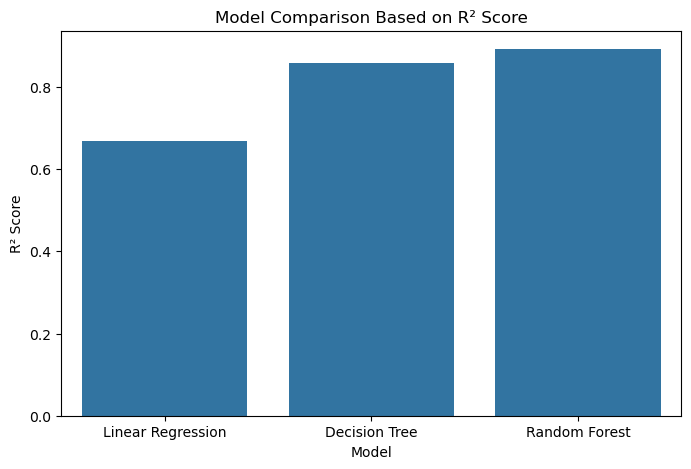

In [46]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='Model',
    y='R² Score',
    data=results)
plt.title("Model Comparison Based on R² Score")
plt.ylabel("R² Score")
plt.show()

** ACTUAL VS PREDICTEDRANDOM FOREST**

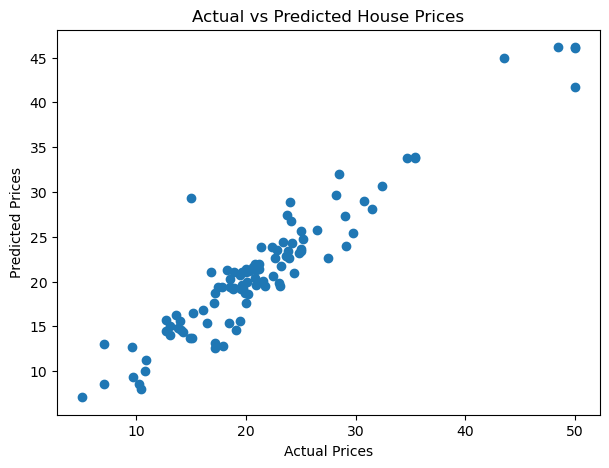

In [49]:
plt.figure(figsize=(7,5))
plt.scatter(
    y_test,
    rf_predictions
)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

**FEATURE IMPORTANCE RANDOM FOREST**

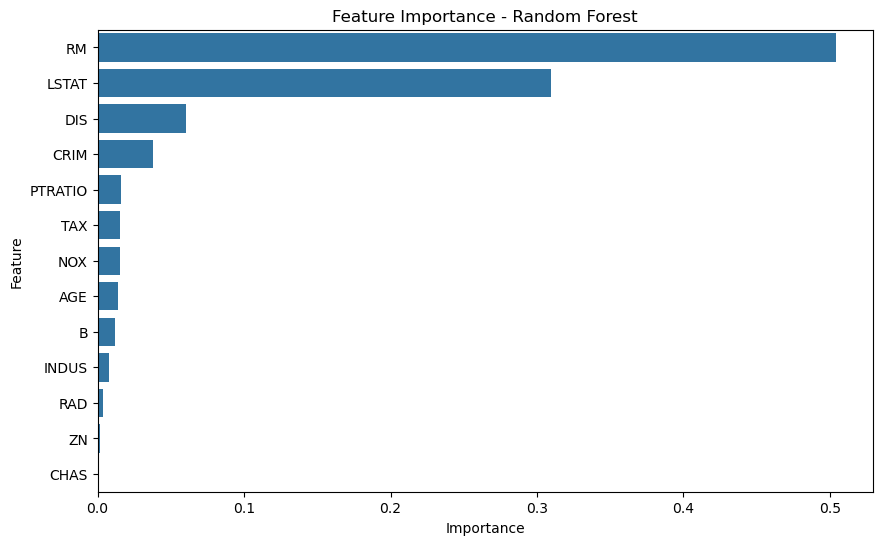

In [52]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.title("Feature Importance - Random Forest")
plt.show()
